# Relegation battle competitiveness — visual summary

This notebook **only reads** precomputed CSVs from `data/processed/relegation_competitiveness/` (metrics are **not** recomputed here).

**Inputs**
- `metric1_relegation_contenders_index.csv`
- `metric3_survival_gap.csv`
- `metric4_relegation_zone_volatility.csv`

Plots are saved as PNG under `data/processed/relegation_competitiveness/plots/`.


In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("ggplot")
    except OSError:
        pass

from scipy import stats

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="muted")
except ImportError:
    pass

def resolve_notebooks_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "data" / "processed" / "relegation_competitiveness").is_dir():
            return base
        nb = base / "notebooks"
        if (nb / "data" / "processed" / "relegation_competitiveness").is_dir():
            return nb
    raise FileNotFoundError("Could not find data/processed/relegation_competitiveness")

ROOT = resolve_notebooks_root()
PROC = ROOT / "data" / "processed" / "relegation_competitiveness"
PLOT_DIR = PROC / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def season_sort_key(series: pd.Series):
    def one(s):
        if not isinstance(s, str) or "/" not in s:
            return 0
        a, b = s.split("/", 1)
        try:
            return int(a) * 100 + int(b)
        except ValueError:
            return 0

    return series.map(one)


def sort_by_season(df: pd.DataFrame, col="season"):
    out = df.copy()
    out["_k"] = season_sort_key(out[col])
    return out.sort_values("_k").drop(columns="_k").reset_index(drop=True)


## Load and merge datasets

`metric3` stores the survival margin as **`points_gap_survival`** (points difference between lowest safe club and highest relegated / relevant pair). Charts label this as **points gap to survival**.


In [2]:
m1 = pd.read_csv(PROC / "metric1_relegation_contenders_index.csv")
m3 = pd.read_csv(PROC / "metric3_survival_gap.csv")
m4 = pd.read_csv(PROC / "metric4_relegation_zone_volatility.csv")

df = (
    m1[["season", "n_relegation_contenders"]]
    .merge(
        m3[["season", "points_gap_survival", "gd_gap_survival"]],
        on="season",
        how="inner",
    )
    .merge(
        m4[["season", "total_relegation_zone_changes", "unique_teams_ever_in_zone"]],
        on="season",
        how="inner",
    )
)
df = sort_by_season(df)
df.tail()


,season,n_relegation_contenders,points_gap_survival,gd_gap_survival,total_relegation_zone_changes,unique_teams_ever_in_zone
14,2020/21,6,1,-4,13,6
15,2021/22,4,6,-1,15,8
16,2022/23,6,2,-9,21,6
17,2023/24,6,3,-5,11,6
18,2024/25,6,2,2,2,4


## Visualization 1 — Competitiveness trend (survival gap)

Line chart of **`points_gap_survival`** vs season.

**Interpretation:** Lower gap usually means closer margins near the relegation cut — typically a **tighter relegation battle** (more competitive in that sense).

**Plot title:** *Relegation Battle Closeness Over Time*.


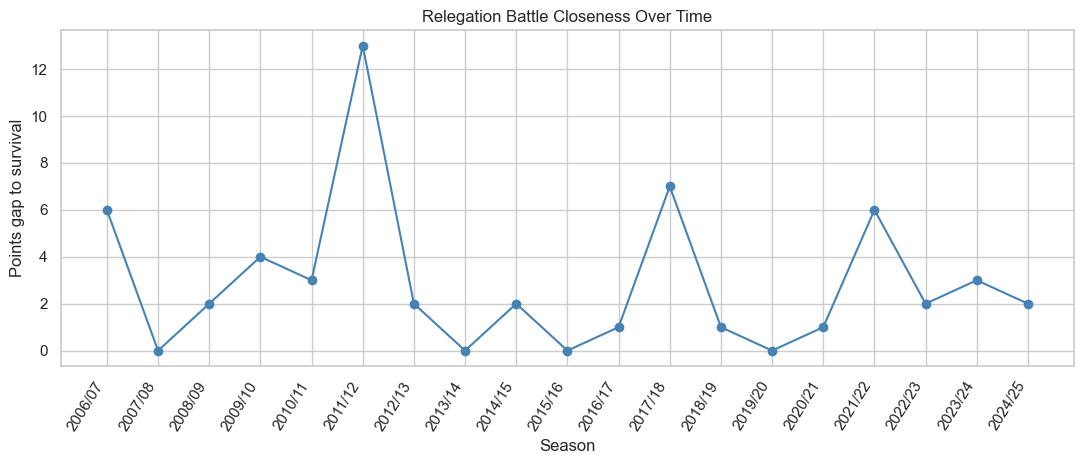

Saved C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\processed\relegation_competitiveness\plots\viz1_survival_gap_trend.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(df["season"], df["points_gap_survival"], marker="o", color="steelblue")
ax.set_xlabel("Season")
ax.set_ylabel("Points gap to survival")
ax.set_title("Relegation Battle Closeness Over Time")
plt.xticks(rotation=58, ha="right")
fig.tight_layout()
p1 = PLOT_DIR / "viz1_survival_gap_trend.png"
fig.savefig(p1, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", p1)


## Visualization 2 — Relegation zone volatility

Bar chart of **`total_relegation_zone_changes`** (Metric 4).

**Interpretation:** Higher bars mean **more churn** in who occupies the relegation-zone snapshot between consecutive TM rounds — a more dynamic relegation picture.


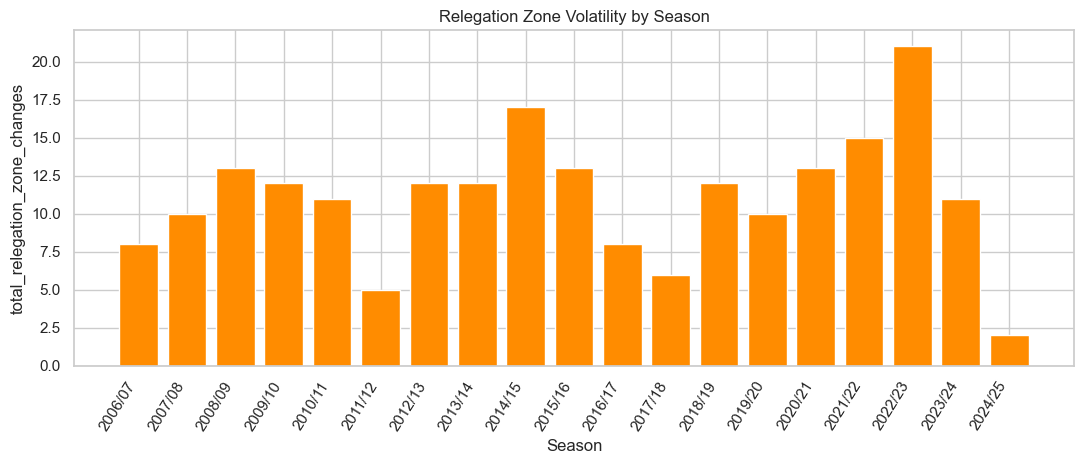

Saved C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\processed\relegation_competitiveness\plots\viz2_zone_volatility_bars.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(df))
ax.bar(x, df["total_relegation_zone_changes"], color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(df["season"], rotation=58, ha="right")
ax.set_xlabel("Season")
ax.set_ylabel("total_relegation_zone_changes")
ax.set_title("Relegation Zone Volatility by Season")
fig.tight_layout()
p2 = PLOT_DIR / "viz2_zone_volatility_bars.png"
fig.savefig(p2, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", p2)


## Visualization 3 — Number of contenders

Line chart — **`n_relegation_contenders`** from Metric 1.


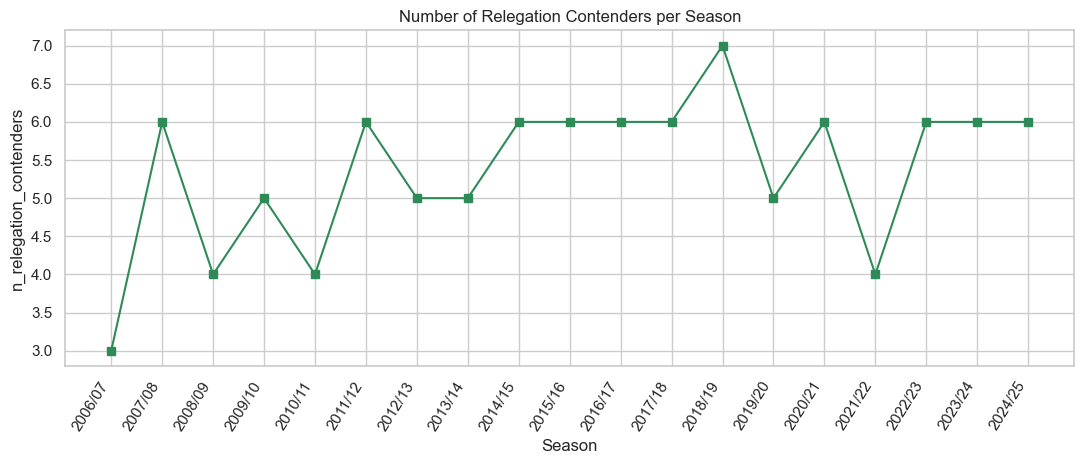

Saved C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\processed\relegation_competitiveness\plots\viz3_contenders_per_season.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(df["season"], df["n_relegation_contenders"], marker="s", color="seagreen")
ax.set_xlabel("Season")
ax.set_ylabel("n_relegation_contenders")
ax.set_title("Number of Relegation Contenders per Season")
plt.xticks(rotation=58, ha="right")
fig.tight_layout()
p3 = PLOT_DIR / "viz3_contenders_per_season.png"
fig.savefig(p3, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", p3)


## Visualization 4 — Closeness vs volatility

Scatter: **`points_gap_survival`** (x) vs **`total_relegation_zone_changes`** (y), with ordinary least-squares line.


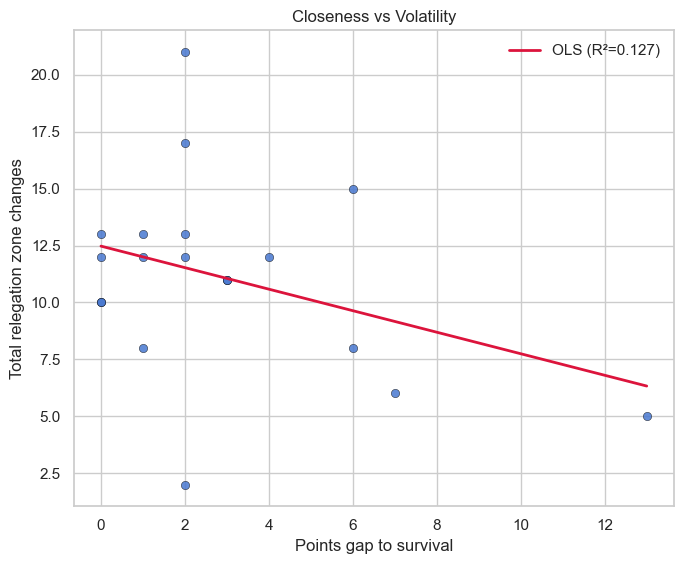

Saved C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\processed\relegation_competitiveness\plots\viz4_closeness_vs_volatility_scatter.png
Pearson r (survival gap vs zone changes): -0.3568


In [6]:
clean = df.dropna(subset=["points_gap_survival", "total_relegation_zone_changes"]).copy()

fig, ax = plt.subplots(figsize=(7, 5.8))
ax.scatter(
    clean["points_gap_survival"],
    clean["total_relegation_zone_changes"],
    alpha=0.85,
    edgecolors="black",
    linewidths=0.35,
)

if len(clean) >= 2:
    x = clean["points_gap_survival"].to_numpy(dtype=float)
    y = clean["total_relegation_zone_changes"].to_numpy(dtype=float)
    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    xs = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), 100)
    ax.plot(xs, intercept + slope * xs, color="crimson", linewidth=2, label=f"OLS (R²={r_val**2:.3f})")
    ax.legend()

ax.set_xlabel("Points gap to survival")
ax.set_ylabel("Total relegation zone changes")
ax.set_title("Closeness vs Volatility")
fig.tight_layout()
p4 = PLOT_DIR / "viz4_closeness_vs_volatility_scatter.png"
fig.savefig(p4, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", p4)

rpear = clean["points_gap_survival"].corr(clean["total_relegation_zone_changes"])
print(f"Pearson r (survival gap vs zone changes): {rpear:.4f}")


## Bonus — Season deep-dive: league position vs round (bottom-strip teams)

Loads **existing TM tracking snapshots** (`regular_season_tracking` + `all_seasons_relegation_tracking`) for **`DEEP_DIV_SEASON`** — no competitiveness metrics recomputed — and plots league **position vs round** for teams that appear in **the worst four ladder positions at least once** (rough bottom-strip focus).

Adjust `DEEP_DIV_SEASON` below to explore another year.


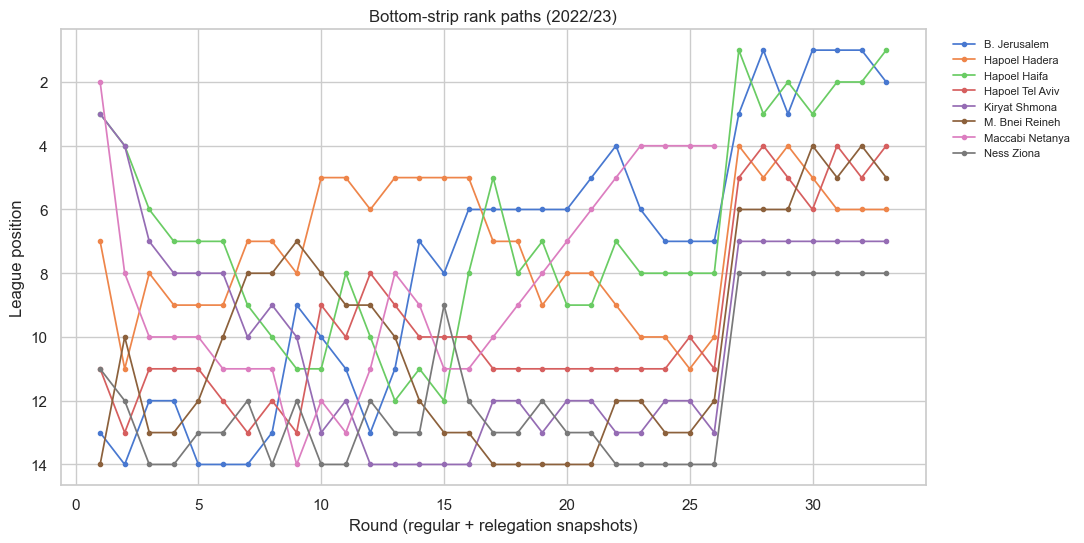

Saved C:\Users\nitib\dev-lab\ligat_haal_project\ligat_haal_project\notebooks\data\processed\relegation_competitiveness\plots\viz5_bonus_rank_paths_2022_23.png


In [7]:
DEEP_DIV_SEASON = "2022/23"

SAFE = DEEP_DIV_SEASON.replace("/", "_")
reg_path = ROOT / "data" / "regular_season_tracking" / f"regular_season_tracking_{SAFE}.csv"
rel_all = ROOT / "data" / "relegation_playoff_tracking" / "all_seasons_relegation_tracking.csv"

chunks: list = []
if reg_path.is_file():
    chunks.append(pd.read_csv(reg_path))
else:
    print("WARN missing", reg_path)

if rel_all.is_file():
    ra = pd.read_csv(rel_all)
    chunks.append(ra[ra["season"].astype(str).str.strip() == DEEP_DIV_SEASON.strip()])

if not chunks:
    raise FileNotFoundError("No tracking data for bonus plot")

trac = pd.concat(chunks, ignore_index=True)
trac["round"] = pd.to_numeric(trac["round"], errors="coerce")
trac["position"] = pd.to_numeric(trac["position"], errors="coerce")
trac = trac.dropna(subset=["round", "position", "team"]).sort_values(["round", "stage"])
trac["team"] = trac["team"].astype(str).str.strip()

n_tab = int(trac["position"].max())
bottom_strip = range(max(1, n_tab - 3), n_tab + 1)

focus = set()
for _, row in trac.iterrows():
    if int(row["position"]) in bottom_strip:
        focus.add(row["team"])

trac_f = trac[trac["team"].isin(focus)]

fig, ax = plt.subplots(figsize=(11, 5.6))
for tm, grp in trac_f.groupby("team"):
    grp = grp.sort_values(["round", "stage"]).drop_duplicates(subset=["round"], keep="last")
    ax.plot(grp["round"], grp["position"], marker=".", linewidth=1.25, label=tm)

ax.invert_yaxis()
ax.set_xlabel("Round (regular + relegation snapshots)")
ax.set_ylabel("League position")
ax.set_title(f"Bottom-strip rank paths ({DEEP_DIV_SEASON})")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
fig.tight_layout()
p5 = PLOT_DIR / f"viz5_bonus_rank_paths_{SAFE}.png"
fig.savefig(p5, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", p5)


---

## Closing insights — questions

Use printed summaries from the notebook code above (correlations / top-season tables).

**Is the league becoming more competitive?**  
Judge from Visualization 1: a **multi-year declining** points gap implies **tighter battles** relative to survival. Combine with contenders (Visualization 3) — more teams in contention can coexist with tighter or wider gaps.

**Which seasons looked most dramatic?**  
Years with **especially low points gap**, **many contenders**, **high zone churn**, or all three simultaneously (see outliers on Visualization 4).

**Are closeness and volatility correlated?**  
Read **Pearson r** under Visualization 4: close-to-zero correlations mean competitiveness and reshuffling behave differently across seasons.

**Which metric fits “competitiveness” best?**  
Metrics answer different notions: **survival gap (Metric 3)** for **margin tightness**; **Metric 4 churn** for **how restless the relegation-zone membership is**; **Metric 1 contender count** for **how crowded the danger band is**. No single KPI captures all meanings.


In [8]:
print("Smallest points_gap_survival (= tightest margins, among loaded seasons)\n")
print(df.nsmallest(5, "points_gap_survival")[["season", "points_gap_survival"]].to_string(index=False))

print("\nHighest total_relegation_zone_changes\n")
print(df.nlargest(5, "total_relegation_zone_changes")[["season", "total_relegation_zone_changes"]].to_string(index=False))


Smallest points_gap_survival (= tightest margins, among loaded seasons)

 season  points_gap_survival
2007/08                    0
2013/14                    0
2015/16                    0
2019/20                    0
2016/17                    1

Highest total_relegation_zone_changes

 season  total_relegation_zone_changes
2022/23                             21
2014/15                             17
2021/22                             15
2008/09                             13
2015/16                             13
